# Flexible SBI with an Epydemix SEIR model

This notebook is an Epydemix-based analogue of
[`3_flexible_sbi_example_SEIR.ipynb`](https://github.com/albazarova/sbi_intro/blob/main/notebooks/3_flexible_sbi_example_SEIR.ipynb).
It keeps the same teaching arc:

- define a change-point SEIR simulator;
- inspect prior-predictive trajectories;
- train an amortized neural posterior;
- focus inference with two sequential rounds;
- compare full trajectories with an observation-aware summary statistic;
- show where simulation parallelism enters the workflow.

The simulator uses the maintained
[`epydemix` package](https://pypi.org/project/epydemix/) (spelled with “py”).
Epydemix provides a stochastic compartmental simulator and accepts time-varying
rate arrays directly, so the intervention change point can be represented without
subclassing internal solver code.


## Setup

Uncomment the installation line if the packages are not already available in
this kernel. The notebook targets the Epydemix 1.3 API.


In [1]:
# %pip install "epydemix>=1.3,<2" "sbi>=0.22" pandas matplotlib


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from epydemix import EpiModel
from sbi.analysis import pairplot
from sbi.inference import simulate_for_sbi
from sbi.utils import BoxUniform

# `SNPE` was renamed to `NPE`; this keeps the notebook usable across sbi releases.
try:
    from sbi.inference import NPE as PosteriorInference
except ImportError:
    from sbi.inference import SNPE as PosteriorInference

torch.manual_seed(16)
np.random.seed(16)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 1       # Set to -1 to use all local CPU cores.
NUM_SIMS = 2_000      # Try 10_000 for results closer to the original notebook.
NUM_POSTERIOR_SAMPLES = 5_000
print(f"Training device: {DEVICE}")


Training device: cuda


## RKI data

We reuse the preprocessed RKI series from the source repository. The loader first
looks beside this notebook and in `../data/`, then falls back to GitHub. Keeping
the local CSV beside the notebook makes the example runnable without network access.


In [3]:
DATA_URL = (
    "../data/RKI_data.csv"
)
candidates = [Path("RKI_data.csv"), Path("../data/RKI_data.csv")]
data_path = next((path for path in candidates if path.exists()), None)
data = pd.read_csv(data_path if data_path is not None else DATA_URL)
data["Date"] = pd.to_datetime(data["Date"])
data.head()


,Date,Confirmed,Deaths,Recovered
0,2020-03-01,1902.428571,43.000000,1859.428571
1,2020-03-02,2206.571429,50.142857,2156.428571
2,2020-03-03,2575.857143,59.428571,2516.428571
3,2020-03-04,3034.714286,71.571429,2963.142857
4,2020-03-05,3619.000000,86.285714,3532.714286


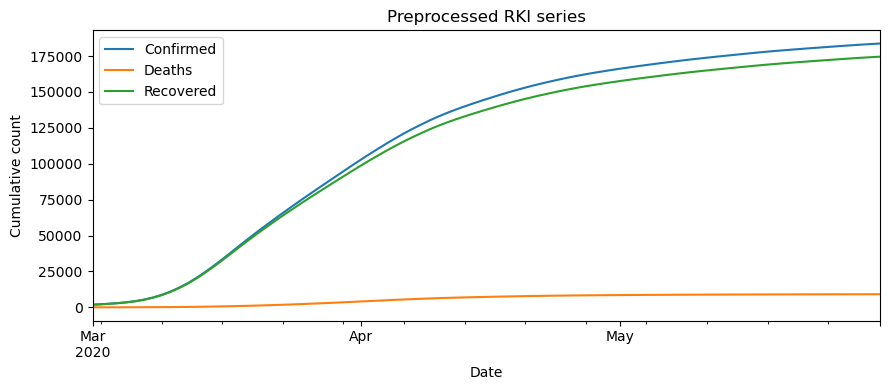

In [4]:
%matplotlib inline
ax = data.plot(x="Date", y=["Confirmed", "Deaths", "Recovered"], figsize=(9, 4))
ax.set_ylabel("Cumulative count")
ax.set_title("Preprocessed RKI series")
plt.tight_layout()
plt.show()


## The SEIR model and simulator

We use the standard population-level model

$$
\frac{dS}{dt}=-\beta(t)\frac{SI}{N},\qquad
\frac{dE}{dt}=\beta(t)\frac{SI}{N}-\alpha E,
$$

$$
\frac{dI}{dt}=\alpha E-\gamma I,\qquad
\frac{dR}{dt}=\gamma I,
$$

with $S+E+I+R=N$ and a change point at $T=18$ days:

$$
\beta(t)=\begin{cases}\beta_1,&t<T\\\beta_2,&t\ge T.\end{cases}
$$

As in the source notebook, the inferred vector is
$\theta=(\beta_1,\Delta_\beta,\Delta_\gamma)$, where
$\beta_2=\max(\beta_1+\Delta_\beta,10^{-4})$ and
$\gamma=\max(\beta_1+\Delta_\gamma,10^{-4})$.
This parameterization expresses the prior belief that intervention reduces
transmission and that recovery is somewhat slower than initial transmission.


In [5]:
def build_seir_model(beta_before, beta_after, gamma):
    '''Build an Epydemix SEIR model with a day-18 transmission change point.'''
    transmission_rate = np.where(
        DAYS < CHANGE_DAY, float(beta_before), float(beta_after)
    )
    model = EpiModel(
        name="change-point SEIR",
        compartments=["Susceptible", "Exposed", "Infected", "Recovered"],
        parameters={
            "transmission_rate": transmission_rate,
            "incubation_rate": ALPHA,
            "recovery_rate": float(gamma),
        },
        default_population_size=N,
    )
    model.add_transition(
        source="Susceptible",
        target="Exposed",
        params=("transmission_rate", "Infected"),
        kind="mediated",
    )
    model.add_transition(
        source="Exposed",
        target="Infected",
        params="incubation_rate",
        kind="spontaneous",
    )
    model.add_transition(
        source="Infected",
        target="Recovered",
        params="recovery_rate",
        kind="spontaneous",
    )
    return model


In [6]:
N = 1_000_000
E0, I0, R0 = 3_000, 1_900, 0
ALPHA = 0.85
CHANGE_DAY = 18.0
DAYS = np.arange(71, dtype=float)
START_DATE = pd.Timestamp("2020-03-01")
END_DATE = START_DATE + pd.Timedelta(days=70)
INITIAL_CONDITIONS = {
    "Susceptible": np.array([N - E0 - I0 - R0]),
    "Exposed": np.array([E0]),
    "Infected": np.array([I0]),
    "Recovered": np.array([R0]),
}


def unpack_parameters(theta):
    theta = torch.as_tensor(theta).detach().cpu().numpy().reshape(-1)
    if theta.size != 3:
        raise ValueError(f"Expected three parameters, received shape {theta.shape}")
    beta1 = float(theta[0])
    beta2 = max(beta1 + float(theta[1]), 1e-4)
    gamma = max(beta1 + float(theta[2]), 1e-4)
    return beta1, beta2, gamma


def simulator(theta):
    '''Return cumulative infected-plus-recovered counts for days 0,...,70.'''
    beta1, beta2, gamma = unpack_parameters(theta)
    model = build_seir_model(beta1, beta2, gamma)
    results = model.run_simulations(
        start_date=START_DATE,
        end_date=END_DATE,
        initial_conditions_dict=INITIAL_CONDITIONS,
        Nsim=1,
        resample_frequency=None,
    )
    trajectory = results.trajectories[0]
    evolved = (
        trajectory.compartments["Infected_total"]
        + trajectory.compartments["Recovered_total"]
    )
    # Epydemix returns post-step states; prepend the supplied day-zero state.
    confirmed_proxy = np.concatenate(([I0 + R0], evolved[:-1]))
    return torch.as_tensor(confirmed_proxy, dtype=torch.float32)


test_output = simulator(torch.tensor([1.0, -0.2, -0.2]))
print(test_output.shape, test_output.dtype, test_output[:3])


torch.Size([71]) torch.float32 tensor([1900., 3634., 5474.])


Epydemix performs stochastic compartment transitions, so repeated calls at the same
parameter values can produce different trajectories. This mirrors the black-box,
stochastic-simulator setting for which SBI is especially useful. A scientific model
could add a separate reporting process (for example, under-ascertainment and delay)
after the latent epidemic simulation.


## Prior distributions

The bounds match the source notebook. `BoxUniform` samples all three components
independently inside the specified ranges.


In [7]:
lower = torch.tensor([0.1, -0.3, -0.2], dtype=torch.float32)
upper = torch.tensor([0.6,  0.1,  0.01], dtype=torch.float32)
prior = BoxUniform(
    low=lower.to(DEVICE),
    high=upper.to(DEVICE),
)
parameter_labels = [
    r"$\beta_1$",
    r"$\beta_2-\beta_1$",
    r"$\gamma-\beta_1$",
]
limits = torch.stack((lower, upper), dim=1)


## Prior-predictive check

Simulating before training checks whether the observed trajectory lies within the
range implied by the prior. Grey curves are Epydemix simulations and black is the
first 71 observations.


  0%|          | 0/100 [00:00<?, ?it/s]

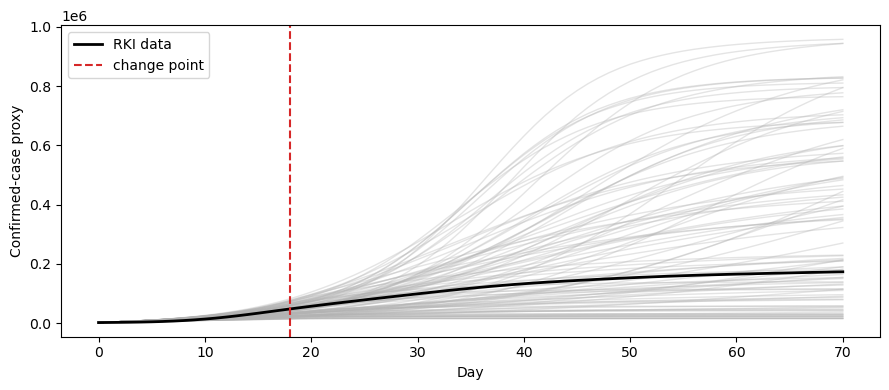

In [8]:
y_o = torch.as_tensor(data["Confirmed"].iloc[:71].to_numpy(), dtype=torch.float32)

theta_preview, x_preview = simulate_for_sbi(
    simulator=simulator,
    proposal=prior,
    num_simulations=100,
    num_workers=NUM_WORKERS,
)
# Older sbi releases flatten each simulator output; this is a no-op otherwise.
x_preview = x_preview.reshape(100, len(DAYS))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(DAYS, x_preview.T.numpy(), color="0.7", alpha=0.35, linewidth=1)
ax.plot(DAYS, y_o.numpy(), color="black", linewidth=2, label="RKI data")
ax.axvline(CHANGE_DAY, color="tab:red", linestyle="--", label="change point")
ax.set(xlabel="Day", ylabel="Confirmed-case proxy")
ax.legend()
plt.tight_layout()
plt.show()


## Amortized neural posterior estimation

`simulate_for_sbi` separates simulation from neural-network training. Set
`NUM_WORKERS=-1` to parallelize independent Epydemix simulations over local cores.
Both returned arrays are `float32` tensors with shapes `(simulations, 3)` and
`(simulations, 71)`.


In [9]:
theta, x = simulate_for_sbi(
    simulator=simulator,
    proposal=prior,
    num_simulations=NUM_SIMS,
    num_workers=NUM_WORKERS,
)
theta = theta.to(torch.float32)
x = x.reshape(NUM_SIMS, len(DAYS)).to(torch.float32)
print("theta:", theta.shape, theta.dtype)
print("x:", x.shape, x.dtype)


  0%|          | 0/2000 [00:00<?, ?it/s]

theta: torch.Size([2000, 3]) torch.float32
x: torch.Size([2000, 71]) torch.float32


The default density estimator is a normalizing flow. To experiment with a neural
spline flow, replace the constructor below with
`PosteriorInference(prior=prior, density_estimator="nsf", device=DEVICE)`.


In [10]:
inference = PosteriorInference(prior=prior, device=DEVICE)
density_estimator = inference.append_simulations(theta, x).train()
posterior = inference.build_posterior(density_estimator)


/p/scratch/training2637/venv/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:199: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'cuda:0'. Training will proceed on device 'cuda:0'.
  theta, x = validate_theta_and_x(
/p/scratch/training2637/venv/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has constant values in dimension(s) [0]. These dimensions carry no information and will be mapped to zero after z-scoring. Consider removing constant features from your data.
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 242 epochs.

In [11]:
samples = posterior.sample(
    (NUM_POSTERIOR_SAMPLES,), x=y_o.to(DEVICE)
).detach().cpu()
samples.shape


  0%|          | 0/5000 [00:00<?, ?it/s]

torch.Size([5000, 3])

### Posterior visualization

The helper handles the small plotting-API difference between older `SNPE`-era
releases and newer `NPE` releases of `sbi`.


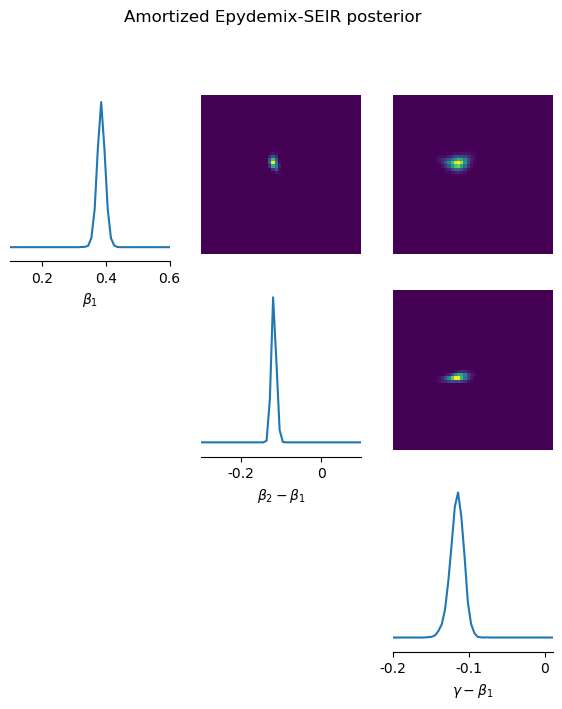

In [12]:
def posterior_pairplot(samples, title):
    kwargs = dict(
        samples=samples,
        limits=limits,
        labels=parameter_labels,
        diag="kde",
        upper="kde",
    )
    try:
        fig, axes = pairplot(**kwargs, figsize=(7, 7))
    except TypeError:
        fig, axes = pairplot(**kwargs, fig_kwargs={"fig_size": (7, 7)})
    fig.suptitle(title, y=1.02)
    return fig, axes


posterior_pairplot(samples, "Amortized Epydemix-SEIR posterior")
plt.show()


### Posterior-predictive sanity check

We compare the trajectory at the posterior mean and a small set of posterior
draws with the observed RKI curve.


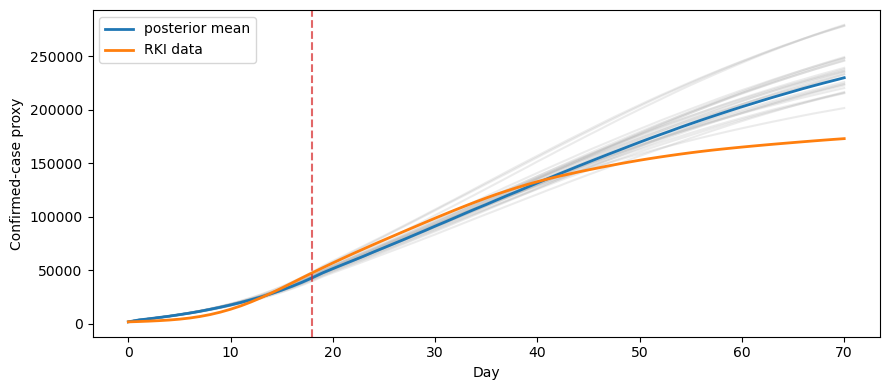

In [13]:
posterior_mean_curve = simulator(samples.mean(dim=0))
predictive_curves = torch.stack([simulator(draw) for draw in samples[:25]])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(DAYS, predictive_curves.T.numpy(), color="0.7", alpha=0.25)
ax.plot(DAYS, posterior_mean_curve.numpy(), label="posterior mean", linewidth=2)
ax.plot(DAYS, y_o.numpy(), label="RKI data", linewidth=2)
ax.axvline(CHANGE_DAY, color="tab:red", linestyle="--", alpha=0.7)
ax.set(xlabel="Day", ylabel="Confirmed-case proxy")
ax.legend()
plt.tight_layout()
plt.show()


## Sequential inference

Two rounds focus the simulation budget on this particular observation. The first
proposal is the prior; the posterior conditioned on `y_o` becomes the next proposal.
Unlike single-round inference, the result is no longer broadly amortized over other
observations.


In [14]:
NUM_ROUNDS = 2
SIMS_PER_ROUND = max(500, NUM_SIMS // NUM_ROUNDS)
inference_seq = PosteriorInference(prior=prior, device=DEVICE)
proposal = prior
round_posteriors = []

for round_index in range(NUM_ROUNDS):
    theta_r, x_r = simulate_for_sbi(
        simulator=simulator,
        proposal=proposal,
        num_simulations=SIMS_PER_ROUND,
        num_workers=NUM_WORKERS,
    )
    x_r = x_r.reshape(SIMS_PER_ROUND, len(DAYS))
    density_r = inference_seq.append_simulations(
        theta_r.to(torch.float32),
        x_r.to(torch.float32),
        proposal=proposal,
    ).train()
    posterior_r = inference_seq.build_posterior(density_r)
    proposal = posterior_r.set_default_x(y_o.to(DEVICE))
    round_posteriors.append(posterior_r)
    print(f"Finished round {round_index + 1}/{NUM_ROUNDS}")

posterior_sequential = round_posteriors[-1]
samples_sequential = posterior_sequential.sample(
    (NUM_POSTERIOR_SAMPLES,), x=y_o.to(DEVICE)
).detach().cpu()


  0%|          | 0/1000 [00:00<?, ?it/s]

/p/scratch/training2637/venv/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:199: UserWarning: Data x has device 'cpu'. Moving x to the data_device 'cuda:0'. Training will proceed on device 'cuda:0'.
  theta, x = validate_theta_and_x(
/p/scratch/training2637/venv/lib/python3.13/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has constant values in dimension(s) [0]. These dimensions carry no information and will be mapped to zero after z-scoring. Consider removing constant features from your data.
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 428 epochs.Finished round 1/2


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Using NPE_C with atomic loss
 Neural network successfully converged after 51 epochs.Finished round 2/2


  0%|          | 0/5000 [00:00<?, ?it/s]

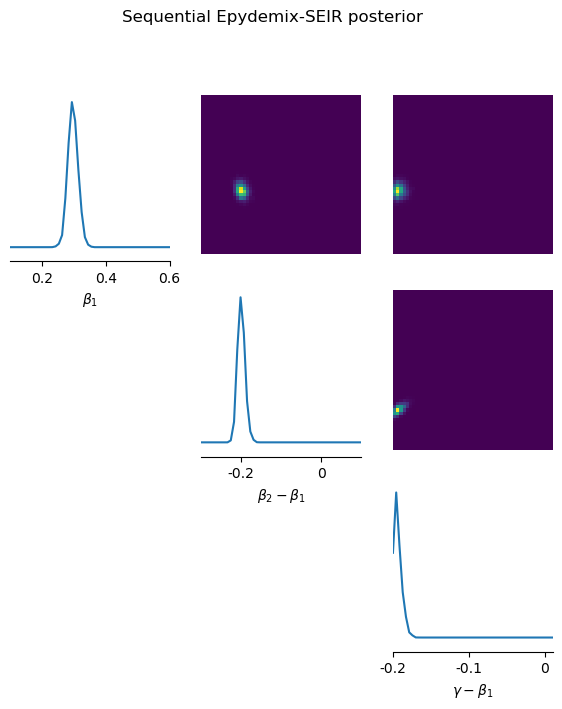

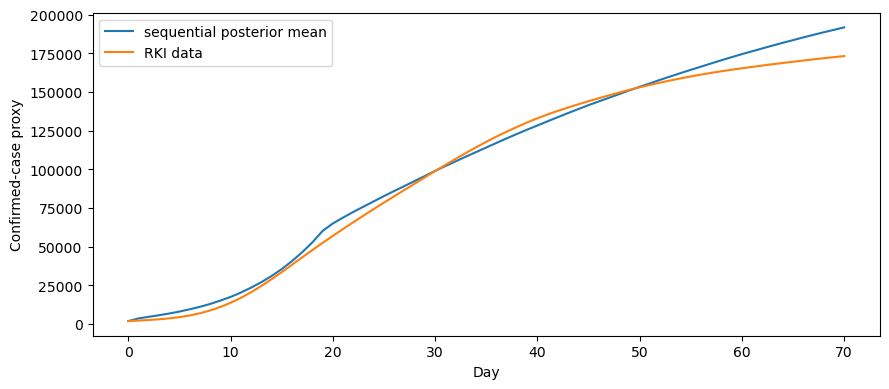

In [15]:
posterior_pairplot(samples_sequential, "Sequential Epydemix-SEIR posterior")
plt.show()

sequential_mean_curve = simulator(samples_sequential.mean(dim=0))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(DAYS, sequential_mean_curve.numpy(), label="sequential posterior mean")
ax.plot(DAYS, y_o.numpy(), label="RKI data")
ax.set(xlabel="Day", ylabel="Confirmed-case proxy")
ax.legend()
plt.tight_layout()
plt.show()


## Learning from an observation-aware summary statistic

Here the 71-dimensional trajectory is reduced to one number: log mean-squared
error from the specific observation. The matching observed summary is zero because
`log1p(MSE(y_o, y_o)) = 0`.

This can focus inference sharply, but it ties the trained network to this one
observation. It is unsuitable when one amortized posterior must serve many datasets.


In [16]:
def log_mse_summary(simulations, observation):
    simulations = torch.as_tensor(simulations, dtype=torch.float32)
    observation = torch.as_tensor(observation, dtype=torch.float32).reshape(1, -1)
    mse = torch.mean((simulations - observation) ** 2, dim=1, keepdim=True)
    return torch.log1p(mse)
    #return mse


x_summary = log_mse_summary(x, y_o)
observed_summary = torch.zeros(1, dtype=torch.float32)
print(x_summary.shape, x_summary.min().item(), x_summary.max().item())


torch.Size([2000, 1]) 15.96914005279541 26.426908493041992


 Neural network successfully converged after 499 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

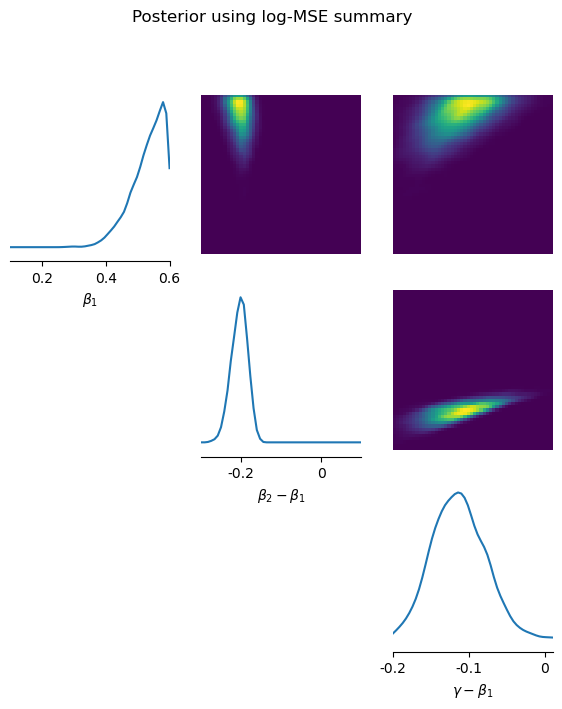

In [17]:
inference_summary = PosteriorInference(prior=prior, device=DEVICE)
density_summary = inference_summary.append_simulations(theta, x_summary).train()
posterior_summary = inference_summary.build_posterior(density_summary)
samples_summary = posterior_summary.sample(
    (NUM_POSTERIOR_SAMPLES,), x=observed_summary.to(DEVICE)
).detach().cpu()

posterior_pairplot(samples_summary, "Posterior using log-MSE summary")
plt.show()


## Comparing fitted trajectories


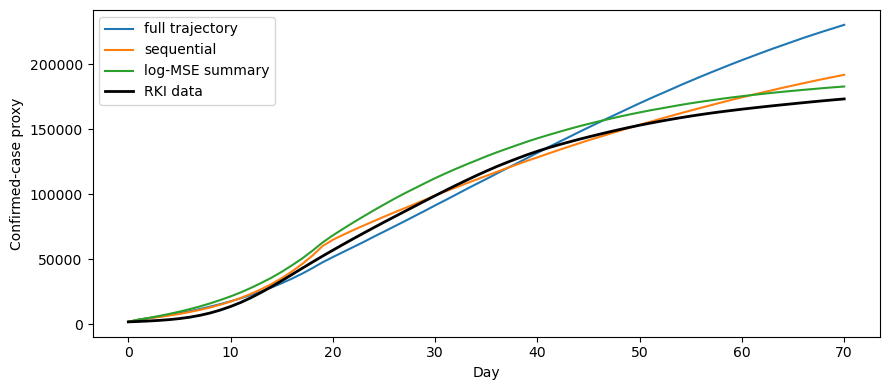

In [18]:
summary_mean_curve = simulator(samples_summary.mean(dim=0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(DAYS, posterior_mean_curve.numpy(), label="full trajectory")
ax.plot(DAYS, sequential_mean_curve.numpy(), label="sequential")
ax.plot(DAYS, summary_mean_curve.numpy(), label="log-MSE summary")
ax.plot(DAYS, y_o.numpy(), color="black", linewidth=2, label="RKI data")
ax.set(xlabel="Day", ylabel="Confirmed-case proxy")
ax.legend()
plt.tight_layout()
plt.show()


## Parallel and multi-node simulation

For one machine, set `NUM_WORKERS=-1` in the setup cell. Epydemix simulations are
independent, so they are natural units of parallel work. In notebooks—especially
on macOS—start with one worker to avoid process-spawning surprises.

For a cluster, generate `(theta, x)` shards in separate jobs, save them, concatenate
the tensors, and call `append_simulations` once. This is usually more robust than
patching `sbi` internals. The neural-network training can then run on a GPU node.

## Notes and limitations

- `I + R` is used as a simple proxy for cumulative confirmed cases, matching the
  source notebook. A scientific analysis should add reporting delay, ascertainment,
  deaths, and a calibrated observation model.
- Epydemix's compartment transitions are stochastic. Reporting and measurement
  noise should still be modeled explicitly when uncertainty calibration matters.
- Increase `NUM_SIMS`, inspect posterior-predictive checks, and run SBI diagnostics
  before interpreting the posterior substantively.

Useful references: [Epydemix on PyPI](https://pypi.org/project/epydemix/),
[current `sbi` getting-started tutorial](https://sbi-dev.github.io/sbi/latest/tutorials/00_getting_started/),
and the [source PyRoss notebook](https://github.com/albazarova/sbi_intro/blob/main/notebooks/3_flexible_sbi_example_SEIR.ipynb).
